## Function 8 — Week 9: SFGP with qEI Acquisition, 49 samples

This notebook processes the **Week 9** updated data for Function 8 and proposes the next sample point using the same strategy as Week 8:

- **Surrogate**: Single-Fidelity Gaussian Process (SFGP) with Matérn-2.5 kernel, ARD (8 lengthscales), noise lower bound 1e-7, Standardize(m=1)
- **Acquisition**: qExpectedImprovement (qEI) with exploration bonus xi=0.01, 256 MC samples, 30 restarts, 4096 raw samples
- **Fallback**: If all qEI values are 0, select the candidate with highest posterior mean from 4096 Sobol candidates
- **Data**: 49 cumulative samples

**Enhancements (Week 9)**: Three-colour visualisation (blue=initial, orange=submissions, green★=proposed), quantitative performance evaluation (convergence metrics with stalling detection, exploration spread, LOO surrogate error, strategy interpretation).

All hyperparameters are identical to Week 8 — only the data file path and sample count change.

In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import warnings
from itertools import groupby
from scipy.spatial.distance import pdist, squareform

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.acquisition.analytic import ExpectedImprovement
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import ScaleKernel, MaternKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan
from torch.quasirandom import SobolEngine

print("All imports successful.")

All imports successful.


### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Kernel | Matérn-2.5 | Suitable for smooth black-box functions |
| ARD dims | 8 | One lengthscale per input dimension |
| Noise lower bound | 1e-7 | Very tight noise floor for well-behaved outputs |
| Output transform | Standardize(m=1) | BoTorch default z-score standardisation |
| XI | 0.01 | Exploration bonus added to best_f |
| MC_SAMPLES | 256 | Sobol QMC samples for qEI estimation |
| NUM_RESTARTS | 30 | Multi-start for 8D acquisition landscape |
| RAW_SAMPLES | 4096 | Large candidate pool for high-dimensional search |

In [26]:
# ─── Constants (identical to Week 8) ──────────────────────────────────────────
XI          = 0.01    # Exploration bonus: best_f = y_max + XI
MC_SAMPLES  = 256     # Sobol QMC samples for qEI Monte Carlo estimation
NUM_RESTARTS = 30     # Multi-start restarts for 8D acquisition optimisation
RAW_SAMPLES = 4096    # Sobol initial candidates for high-dimensional search
DIM         = 8       # Input dimensionality
BOUNDS = torch.tensor([[0.0] * DIM,
                        [1.0] * DIM], dtype=torch.float64)  # [0,1]⁸

# ── Dataset constants ──
N_INITIAL      = 40
N_TOTAL        = 49
N_DIMS         = 8
N_SUBMISSIONS  = N_TOTAL - N_INITIAL  # 9

# ── Stalling detection ──
STALLING_CONSECUTIVE_THRESHOLD = 3
STALLING_RELATIVE_THRESHOLD    = 0.05

print("Constants:")
print(f"  XI:           {XI}")
print(f"  MC_SAMPLES:   {MC_SAMPLES}")
print(f"  NUM_RESTARTS: {NUM_RESTARTS}")
print(f"  RAW_SAMPLES:  {RAW_SAMPLES}")
print(f"  Bounds:       [0,1]^{DIM}")
print(f"  N_INITIAL={N_INITIAL}, N_TOTAL={N_TOTAL}, N_SUBMISSIONS={N_SUBMISSIONS}")
print(f"  Stalling: consecutive>={STALLING_CONSECUTIVE_THRESHOLD} or relative<{STALLING_RELATIVE_THRESHOLD}")

Constants:
  XI:           0.01
  MC_SAMPLES:   256
  NUM_RESTARTS: 30
  RAW_SAMPLES:  4096
  Bounds:       [0,1]^8
  N_INITIAL=40, N_TOTAL=49, N_SUBMISSIONS=9
  Stalling: consecutive>=3 or relative<0.05


### Step 1: Load Week 9 Data

Load the cumulative Week 9 data (49 total samples).

In [27]:
# Load Week 9 cumulative data
X = np.load('../../data/f8/updated_inputs - Week 9.npy')
y = np.load('../../data/f8/updated_outputs - Week 9.npy')

# Validate dimensions and ranges
assert X.shape == (N_TOTAL, N_DIMS), f"Expected ({N_TOTAL}, {N_DIMS}), got {X.shape}"
assert y.shape == (N_TOTAL,), f"Expected ({N_TOTAL},), got {y.shape}"
assert np.all((X >= 0.0) & (X <= 1.0)), "Inputs out of [0, 1] range"
assert not np.any(np.isnan(y)), "Outputs contain NaN"
assert np.all(y > 0), "Expected all-positive outputs for F8"

# Split initial vs submissions
X_initial, y_initial = X[:N_INITIAL], y[:N_INITIAL]
X_submissions, y_submissions = X[N_INITIAL:], y[N_INITIAL:]

print(f"Week 9 Data: {X.shape[0]} samples, {X.shape[1]} dimensions")
print(f"  Initial samples: {N_INITIAL}, Submissions: {N_SUBMISSIONS}")
print(f"Input range:  [{X.min():.6f}, {X.max():.6f}]")
print(f"Output range: [{y.min():.6f}, {y.max():.6f}]")
print(f"Best observed value: {y.max():.6f} at index {y.argmax()}")
print(f"Best observed point: {X[y.argmax()]}")

# Display tabular data
print(f"\n{'Idx':>4}  {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'x5':>8} {'x6':>8} {'x7':>8} {'x8':>8}  {'y':>10}")
print("-" * 100)
for i in range(len(y)):
    marker = " ← best" if i == y.argmax() else ""
    vals = "  ".join(f"{X[i,j]:.4f}" for j in range(8))
    print(f"{i:>4}  {vals}  {y[i]:>10.6f}{marker}")

Week 9 Data: 49 samples, 8 dimensions
  Initial samples: 40, Submissions: 9
Input range:  [0.000000, 1.000000]
Output range: [5.592193, 9.982473]
Best observed value: 9.982473 at index 47
Best observed point: [0.107773 0.160839 0.142888 0.158839 0.835332 0.507655 0.196162 0.999999]

 Idx        x1       x2       x3       x4       x5       x6       x7       x8           y
----------------------------------------------------------------------------------------------------
   0  0.6050  0.2922  0.9085  0.3555  0.2017  0.5753  0.3103  0.7343    7.398721
   1  0.1780  0.5662  0.9949  0.2103  0.3202  0.7079  0.6354  0.1071    7.005227
   2  0.0091  0.8116  0.5205  0.0757  0.2651  0.0917  0.5924  0.3673    8.459482
   3  0.5060  0.6537  0.3634  0.1780  0.0937  0.1974  0.7558  0.2925    8.284008
   4  0.3599  0.2491  0.4960  0.7092  0.1150  0.2892  0.5573  0.5939    8.606117
   5  0.7788  0.0034  0.3380  0.5195  0.8209  0.5372  0.5513  0.6600    8.541748
   6  0.9086  0.0622  0.2383  0.7666  0

### Step 2: Train SFGP Model (carried from Week 8)

Fit the Single-Fidelity GP with Matérn-2.5, ARD (8 lengthscales), Standardize output transform on 49 samples. Single `fit_gpytorch_mll` call (no restart loop for F8).

In [28]:
# Prepare tensors
X_train_t = torch.tensor(X, dtype=torch.float64)                # shape: [49, 8]
Y_train_t = torch.tensor(y, dtype=torch.float64).unsqueeze(-1)  # shape: [49, 1]

# Define Matérn-2.5 covariance with ARD (one lengthscale per 8 input dimensions)
covar_module = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=DIM))

# Likelihood with very tight noise floor
likelihood = GaussianLikelihood(noise_constraint=GreaterThan(1e-7))

# Build SFGP with default Standardize(m=1) output transform
model = SingleTaskGP(
    train_X=X_train_t,
    train_Y=Y_train_t,
    covar_module=covar_module,
    likelihood=likelihood
).double()

# Fit by maximising the Exact Marginal Log-Likelihood
mll = ExactMarginalLogLikelihood(model.likelihood, model)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_gpytorch_mll(mll)

# Display fitted parameters
lengthscales = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = model.likelihood.noise.detach().item()

print("SFGP Training Complete (8D):")
for i in range(DIM):
    print(f"  Lengthscale x{i+1}: {lengthscales[i]:.6f}")
print(f"  Noise level:      {noise:.8f}  (lower bound: 1e-7)")
print(f"  Outputscale:      {model.covar_module.outputscale.detach().item():.6f}")

# Identify most/least relevant dimensions by lengthscale (shorter = more relevant)
sorted_dims = np.argsort(lengthscales)
print(f"\nDimension relevance (shorter ℓ = more relevant):")
print(f"  Most relevant:  x{sorted_dims[0]+1} (ℓ={lengthscales[sorted_dims[0]]:.4f}), x{sorted_dims[1]+1} (ℓ={lengthscales[sorted_dims[1]]:.4f})")
print(f"  Least relevant: x{sorted_dims[-1]+1} (ℓ={lengthscales[sorted_dims[-1]]:.4f})")

SFGP Training Complete (8D):
  Lengthscale x1: 8.487265
  Lengthscale x2: 11.806656
  Lengthscale x3: 6.850321
  Lengthscale x4: 12.086796
  Lengthscale x5: 17.384755
  Lengthscale x6: 11.679799
  Lengthscale x7: 8.650957
  Lengthscale x8: 1061.984309
  Noise level:      0.00000010  (lower bound: 1e-7)
  Outputscale:      159.879991

Dimension relevance (shorter ℓ = more relevant):
  Most relevant:  x3 (ℓ=6.8503), x1 (ℓ=8.4873)
  Least relevant: x8 (ℓ=1061.9843)


### Step 3: qEI Acquisition Function

Compute **qExpectedImprovement** with `best_f = y_max + XI` for exploration bonus. If all acquisition values are 0, fall back to Sobol-sampled posterior mean selection.

In [29]:
# Build qEI acquisition function
model.eval()
best_f = Y_train_t.max().item() + XI
sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))

qei = qExpectedImprovement(
    model=model,
    best_f=best_f,
    sampler=sampler
)

# Optimise qEI over [0,1]⁸ using multi-start L-BFGS-B
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    candidate, acq_value = optimize_acqf(
        acq_function=qei,
        bounds=BOUNDS,
        q=1,
        num_restarts=NUM_RESTARTS,
        raw_samples=RAW_SAMPLES
    )

acq_val = acq_value.item()
print(f"qEI Acquisition value: {acq_val:.6f}")
print(f"best_f used: {best_f:.6f} (y_max={Y_train_t.max().item():.6f} + XI={XI})")

# Fallback: if acq_val <= 0, use Sobol posterior mean selection
used_fallback = False
if acq_val <= 0:
    print("⚠ All qEI values ≤ 0 — activating Sobol fallback")
    sobol = SobolEngine(dimension=DIM, scramble=True)
    sobol_candidates = sobol.draw(RAW_SAMPLES).to(dtype=torch.float64)
    
    with torch.no_grad():
        posterior = model.posterior(sobol_candidates)
        pred_means = posterior.mean.squeeze()
    
    best_sobol_idx = pred_means.argmax().item()
    candidate = sobol_candidates[best_sobol_idx].unsqueeze(0).unsqueeze(0)
    used_fallback = True
    print(f"  Selected Sobol candidate {best_sobol_idx} with posterior mean {pred_means[best_sobol_idx].item():.6f}")

# Extract proposed next point
next_x = candidate.detach().squeeze()
print(f"\nProposed next point: [{', '.join(f'{next_x[i].item():.6f}' for i in range(DIM))}]")
if used_fallback:
    print("  (via Sobol fallback — highest posterior mean)")

qEI Acquisition value: 0.000000
best_f used: 9.992473 (y_max=9.982473 + XI=0.01)
⚠ All qEI values ≤ 0 — activating Sobol fallback
  Selected Sobol candidate 1760 with posterior mean 9.912958

Proposed next point: [0.103154, 0.164045, 0.170564, 0.364202, 0.972367, 0.604567, 0.275106, 0.739615]
  (via Sobol fallback — highest posterior mean)


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/botorch/acquisition/monte_carlo.py:400: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


### Step 4: Feature Importance

Bar chart showing the inverse lengthscale (1/ℓ) for each dimension — shorter lengthscale = more relevant. Top-2 dimensions highlighted in red.

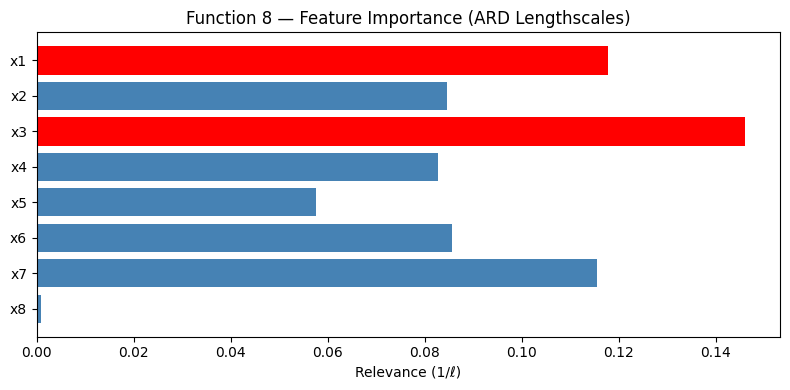

Top-2 most relevant dimensions (red):
  x3: ℓ=6.8503, 1/ℓ=0.1460
  x1: ℓ=8.4873, 1/ℓ=0.1178


In [30]:
# Feature importance: inverse lengthscale (1/ℓ)
importance = 1.0 / lengthscales
sorted_idx = np.argsort(importance)[::-1]  # descending
top2 = set(sorted_idx[:2])

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['red' if i in top2 else 'steelblue' for i in range(DIM)]
dim_labels = [f'x{i+1}' for i in range(DIM)]

ax.barh(dim_labels, importance, color=colors)
ax.set_xlabel('Relevance (1/ℓ)')
ax.set_title('Function 8 — Feature Importance (ARD Lengthscales)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top-2 most relevant dimensions (red):")
for idx in sorted_idx[:2]:
    print(f"  x{idx+1}: ℓ={lengthscales[idx]:.4f}, 1/ℓ={importance[idx]:.4f}")

### Step 5: Visualise SFGP Surrogate

Three-panel 2D slice through the top-2 most relevant dimensions (by shortest ARD lengthscale), with all other dimensions fixed at the best observed point.
- **(a) GP Posterior Mean** (viridis)
- **(b) GP Posterior Std** (magma)
- **(c) Analytic EI** (plasma) — using `ExpectedImprovement` for computational speed

Three-colour scheme: blue=initial, orange=submissions, green★=proposed.

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/botorch/acquisition/analytic.py:340: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


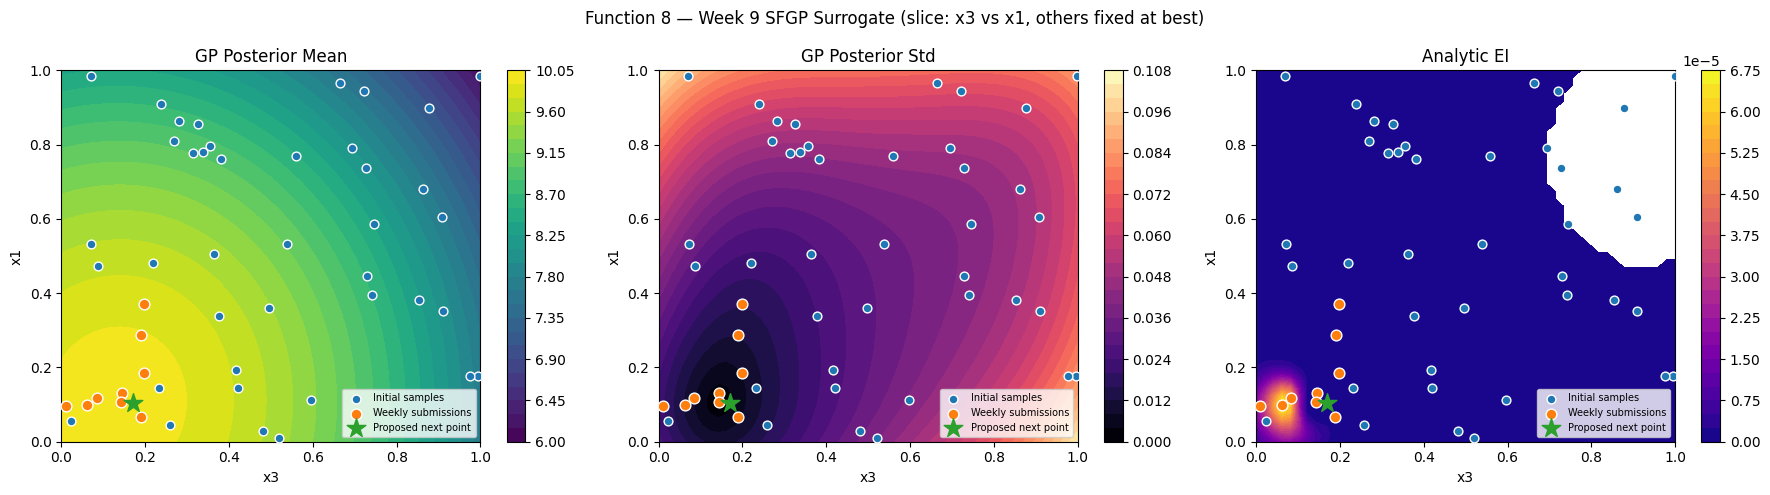

In [31]:
# ── Identify top-2 dimensions and best observed point ─────────────────────────
dim_a, dim_b = sorted_idx[0], sorted_idx[1]  # shortest lengthscales
best_idx = y.argmax()
best_point = X[best_idx]

# ── Build 50×50 grid over top-2 dims, fix others at best observed ─────────────
n_grid = 50
xa_lin = np.linspace(0, 1, n_grid)
xb_lin = np.linspace(0, 1, n_grid)
XA, XB = np.meshgrid(xa_lin, xb_lin)

# Create full 8D grid with fixed dimensions
grid_np = np.tile(best_point, (n_grid * n_grid, 1))
grid_np[:, dim_a] = XA.ravel()
grid_np[:, dim_b] = XB.ravel()
grid_t = torch.tensor(grid_np, dtype=torch.float64)

# ── GP posterior mean and std on grid ─────────────────────────────────────────
model.eval()
with torch.no_grad():
    posterior = model.posterior(grid_t)
    mean_grid = posterior.mean.numpy().reshape(n_grid, n_grid)
    std_grid = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# ── Analytic EI on grid (faster than MC-based qEI for visualisation) ──────────
ei_analytic = ExpectedImprovement(model=model, best_f=best_f)
ei_vals = []
batch_size = 500
for i in range(0, len(grid_np), batch_size):
    batch = grid_t[i:i + batch_size]
    with torch.no_grad():
        ei_vals.append(ei_analytic(batch.unsqueeze(1)).numpy())
ei_grid = np.concatenate(ei_vals).reshape(n_grid, n_grid)

# ── Extract candidate coords in top-2 dims ───────────────────────────────────
cand_a = max(0.0, min(1.0, next_x[dim_a].item()))
cand_b = max(0.0, min(1.0, next_x[dim_b].item()))

# ── Three-panel figure (three-colour scheme) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, cmap, title in zip(
    axes, [mean_grid, std_grid, ei_grid],
    ['viridis', 'magma', 'plasma'],
    ['GP Posterior Mean', 'GP Posterior Std', 'Analytic EI']
):
    c = ax.contourf(XA, XB, data, levels=30, cmap=cmap)
    # Initial samples (blue)
    ax.scatter(X_initial[:, dim_a], X_initial[:, dim_b],
               c='tab:blue', edgecolors='white', s=40, zorder=5, label='Initial samples')
    # Weekly submissions (orange)
    ax.scatter(X_submissions[:, dim_a], X_submissions[:, dim_b],
               c='tab:orange', edgecolors='white', s=60, zorder=5, label='Weekly submissions')
    # Proposed next point (green star)
    ax.scatter(cand_a, cand_b,
               c='tab:green', marker='*', s=200, zorder=6, label='Proposed next point')
    ax.set_xlabel(f'x{dim_a+1}'); ax.set_ylabel(f'x{dim_b+1}')
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=7)
    plt.colorbar(c, ax=ax)

plt.suptitle(f'Function 8 — Week 9 SFGP Surrogate (slice: x{dim_a+1} vs x{dim_b+1}, others fixed at best)', fontsize=12)
plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum across all 48 observations. Weekly boundaries show when each batch of data was collected.

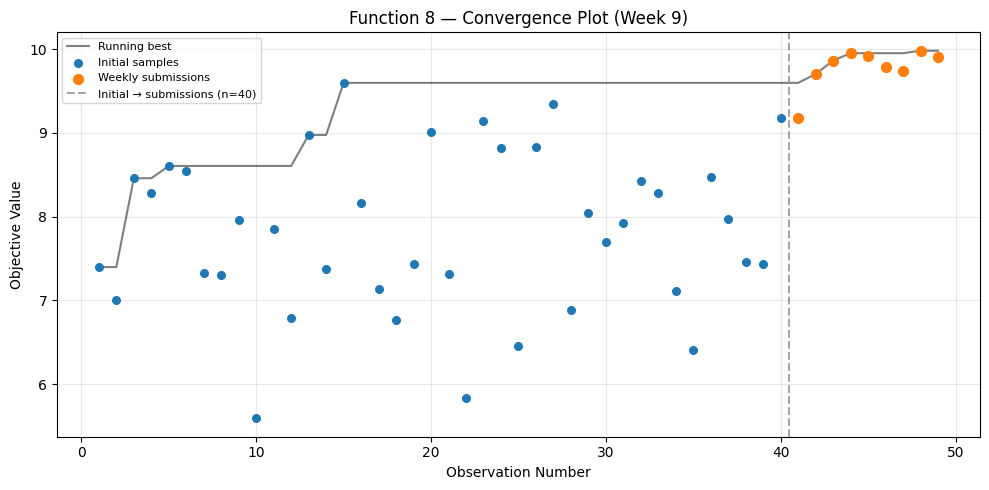

Best initial (sample 1–40): 9.598482
Best overall (sample 1–49): 9.982473
Submissions improved best: Yes ✓


In [32]:
# ── Convergence Plot (three-colour) ──
running_max = np.maximum.accumulate(y)
indices = np.arange(1, len(y) + 1)

plt.figure(figsize=(10, 5))
plt.plot(indices, running_max, 'k-', linewidth=1.5, alpha=0.5, label='Running best')

# Initial observations (blue)
plt.scatter(indices[:N_INITIAL], y[:N_INITIAL],
            c='tab:blue', s=30, zorder=4, label='Initial samples')
# Submission observations (orange)
plt.scatter(indices[N_INITIAL:], y[N_INITIAL:],
            c='tab:orange', s=50, zorder=4, label='Weekly submissions')

# Boundary between initial and submissions
plt.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
            label=f'Initial → submissions (n={N_INITIAL})')

plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 8 — Convergence Plot (Week 9)')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best initial (sample 1–{N_INITIAL}): {y_initial.max():.6f}")
print(f"Best overall (sample 1–{N_TOTAL}): {y.max():.6f}")
improved = y.max() > y_initial.max()
print(f"Submissions improved best: {'Yes ✓' if improved else 'No — initial best retained'}")

### Step 7: Format Submission Query

Format the proposed next sample point as an 8-component string with 6 decimal places, clamped to `[0.0, 0.999999]`.

In [33]:
# Helper function for formatting submission queries
def format_query(point, dim):
    """Clamp each coordinate to [0, 0.999999] and format as submission string."""
    coords = [max(0.0, min(0.999999, point[i].item() if torch.is_tensor(point) else point[i])) for i in range(dim)]
    return "-".join(f"{c:.6f}" for c in coords)

# Format submission
proposed_query = format_query(next_x, DIM)

# Verify no duplicate with existing observations
observed_queries = [format_query(X[i], DIM) for i in range(len(X))]
is_duplicate = proposed_query in observed_queries

print("=" * 80)
print("WEEK 9 SUBMISSION QUERY FOR FUNCTION 8")
print("=" * 80)
print(f"Surrogate:    SFGP (Matérn-2.5, ARD={DIM}d, noise_lb=1e-7, Standardize)")
print(f"Acquisition:  qExpectedImprovement (qEI, XI={XI}, MC={MC_SAMPLES})")
print(f"Fallback:     {'ACTIVATED — Sobol posterior mean' if used_fallback else 'Not needed'}")
print(f"Best observed y: {y.max():.6f}")
print(f"Duplicate check: {'⚠ DUPLICATE' if is_duplicate else 'OK — unique point'}")
print(f"\n>>> SUBMISSION: {proposed_query}")
print("=" * 80)

WEEK 9 SUBMISSION QUERY FOR FUNCTION 8
Surrogate:    SFGP (Matérn-2.5, ARD=8d, noise_lb=1e-7, Standardize)
Acquisition:  qExpectedImprovement (qEI, XI=0.01, MC=256)
Fallback:     ACTIVATED — Sobol posterior mean
Best observed y: 9.982473
Duplicate check: OK — unique point

>>> SUBMISSION: 0.103154-0.164045-0.170564-0.364202-0.972367-0.604567-0.275106-0.739615


### Performance Evaluation — Convergence Metrics & Stalling Detection

In [34]:
# ── Convergence Metrics & Stalling Detection ──
best_initial = y_initial.max()
best_final = y.max()
improvement = best_final - best_initial

# Relative improvement
if abs(best_initial) < 1e-10:
    relative_improvement = 0.0 if improvement < 1e-10 else 1.0
else:
    relative_improvement = improvement / abs(best_initial)

# Per-submission trajectory
submission_bests = [y[:N_INITIAL + k + 1].max() for k in range(N_SUBMISSIONS)]
per_submission_delta = []
new_best_flags = []
for k in range(N_SUBMISSIONS):
    prev = submission_bests[k - 1] if k > 0 else best_initial
    delta = submission_bests[k] - prev
    per_submission_delta.append(delta)
    new_best_flags.append(delta > 0)

# Tail-only consecutive no-improvement (count backwards from most recent)
tail_no_improve = 0
for imp in reversed(per_submission_delta):
    if imp <= 0:
        tail_no_improve += 1
    else:
        break

stalling_consecutive = tail_no_improve >= STALLING_CONSECUTIVE_THRESHOLD
stalling_relative = relative_improvement < STALLING_RELATIVE_THRESHOLD
stalling_flag = stalling_consecutive or stalling_relative

print("=" * 60)
print("CONVERGENCE METRICS")
print("=" * 60)
print(f"  Best initial:         {best_initial:.6f}")
print(f"  Best final:           {best_final:.6f}")
print(f"  Absolute improvement: {improvement:.6f}")
print(f"  Relative improvement: {relative_improvement:.4f} ({relative_improvement*100:.1f}%)")
print(f"\n  Per-submission deltas:")
for k in range(N_SUBMISSIONS):
    week = k + 3  # submissions start at Week 3
    marker = "★" if new_best_flags[k] else " "
    print(f"    Week {week}: Δ = {per_submission_delta[k]:+.6f}  best = {submission_bests[k]:.6f}  {marker}")
print(f"\n  Trailing no-improvement streak: {tail_no_improve}")
print(f"  Stalling (consecutive ≥ {STALLING_CONSECUTIVE_THRESHOLD}): {'YES ⚠' if stalling_consecutive else 'NO ✓'}")
print(f"  Stalling (relative < {STALLING_RELATIVE_THRESHOLD}):  {'YES ⚠' if stalling_relative else 'NO ✓'}")
print(f"  Overall stalling:              {'YES ⚠' if stalling_flag else 'NO ✓'}")

CONVERGENCE METRICS
  Best initial:         9.598482
  Best final:           9.982473
  Absolute improvement: 0.383991
  Relative improvement: 0.0400 (4.0%)

  Per-submission deltas:
    Week 3: Δ = +0.000000  best = 9.598482   
    Week 4: Δ = +0.105588  best = 9.704070  ★
    Week 5: Δ = +0.160973  best = 9.865043  ★
    Week 6: Δ = +0.087982  best = 9.953025  ★
    Week 7: Δ = +0.000000  best = 9.953025   
    Week 8: Δ = +0.000000  best = 9.953025   
    Week 9: Δ = +0.000000  best = 9.953025   
    Week 10: Δ = +0.029448  best = 9.982473  ★
    Week 11: Δ = +0.000000  best = 9.982473   

  Trailing no-improvement streak: 1
  Stalling (consecutive ≥ 3): NO ✓
  Stalling (relative < 0.05):  YES ⚠
  Overall stalling:              YES ⚠


### Performance Evaluation — Exploration Spread

In [35]:
# ── Exploration Spread ──
EXPECTED_UNIFORM = 1.03  # expected mean pairwise distance for 8D uniform [0,1]^8

dists = pdist(X_submissions)
mean_pairwise = dists.mean()

dist_matrix = squareform(dists)
np.fill_diagonal(dist_matrix, np.inf)
nn_dists = dist_matrix.min(axis=1)
max_nn_dist = nn_dists.max()
min_nn_dist = nn_dists.min()

print("=" * 60)
print("EXPLORATION SPREAD (submissions only)")
print("=" * 60)
print(f"  Submission points:      {len(X_submissions)}")
print(f"  Dimensions:             {N_DIMS}")
print(f"  Mean pairwise distance: {mean_pairwise:.4f}  (uniform ≈ {EXPECTED_UNIFORM})")
print(f"  Max NN distance:        {max_nn_dist:.4f}")
print(f"  Min NN distance:        {min_nn_dist:.4f}")

ratio = mean_pairwise / EXPECTED_UNIFORM
if ratio < 0.5:
    spread_status = "CLUSTERED ⚠ — submissions concentrated in small region"
elif ratio < 0.8:
    spread_status = "MODERATE — some clustering, room for more exploration"
else:
    spread_status = "WELL-SPREAD ✓ — good coverage of search space"
print(f"  Spread ratio:           {ratio:.2f} — {spread_status}")

EXPLORATION SPREAD (submissions only)
  Submission points:      9
  Dimensions:             8
  Mean pairwise distance: 0.8189  (uniform ≈ 1.03)
  Max NN distance:        0.8821
  Min NN distance:        0.1951
  Spread ratio:           0.80 — MODERATE — some clustering, room for more exploration


### Performance Evaluation — Leave-One-Out Surrogate Error (SFGP)

In [36]:
# ── LOO Surrogate Error (SFGP retrain, 9 folds over submissions) ──
loo_predictions = []
loo_actuals = []

for fold in range(N_SUBMISSIONS):
    hold_idx = N_INITIAL + fold  # index into full dataset

    # Build LOO dataset: all points except held-out
    mask = np.ones(N_TOTAL, dtype=bool)
    mask[hold_idx] = False
    X_loo = X[mask]
    y_loo = y[mask]

    # Prepare tensors
    X_loo_t = torch.tensor(X_loo, dtype=torch.float64)
    Y_loo_t = torch.tensor(y_loo, dtype=torch.float64).unsqueeze(-1)

    # Retrain SFGP from scratch (Standardize auto-recomputes z-score)
    covar_loo = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=DIM))
    lik_loo = GaussianLikelihood(noise_constraint=GreaterThan(1e-7))
    gp_loo = SingleTaskGP(
        train_X=X_loo_t,
        train_Y=Y_loo_t,
        covar_module=covar_loo,
        likelihood=lik_loo
    ).double()

    mll_loo = ExactMarginalLogLikelihood(gp_loo.likelihood, gp_loo)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit_gpytorch_mll(mll_loo)

    # Predict on held-out point
    gp_loo.eval()
    x_held = torch.tensor(X[hold_idx:hold_idx+1], dtype=torch.float64)
    with torch.no_grad():
        pred = gp_loo.posterior(x_held).mean.item()

    loo_predictions.append(pred)
    loo_actuals.append(y[hold_idx])

loo_predictions = np.array(loo_predictions)
loo_actuals = np.array(loo_actuals)
loo_errors = loo_predictions - loo_actuals
loo_mae = np.mean(np.abs(loo_errors))
loo_rmse = np.sqrt(np.mean(loo_errors**2))

print("=" * 60)
print("LOO SURROGATE ERROR (SFGP retrain, 9 folds)")
print("=" * 60)
print(f"  MAE:  {loo_mae:.6f}")
print(f"  RMSE: {loo_rmse:.6f}")
print(f"\n  Per-fold results:")
print(f"  {'Fold':>4s}  {'Actual':>10s}  {'Predicted':>10s}  {'Error':>10s}  {'|Error|':>10s}")
for i in range(N_SUBMISSIONS):
    print(f"  {i+1:4d}  {loo_actuals[i]:10.6f}  {loo_predictions[i]:10.6f}  "
          f"{loo_errors[i]:+10.6f}  {abs(loo_errors[i]):10.6f}")
print(f"\n  Note: LOO on {N_SUBMISSIONS} submission points only.")
print(f"  SFGP (Matérn 2.5, ARD={N_DIMS}d) retrained from scratch per fold.")
print(f"  Standardize(m=1) auto-recomputes z-score per fold.")

LOO SURROGATE ERROR (SFGP retrain, 9 folds)
  MAE:  0.013243
  RMSE: 0.019661

  Per-fold results:
  Fold      Actual   Predicted       Error     |Error|
     1    9.180475    9.174002   -0.006473    0.006473
     2    9.704070    9.700465   -0.003605    0.003605
     3    9.865043    9.902373   +0.037330    0.037330
     4    9.953025    9.951764   -0.001261    0.001261
     5    9.915842    9.921319   +0.005478    0.005478
     6    9.786290    9.784741   -0.001549    0.001549
     7    9.739214    9.779586   +0.040372    0.040372
     8    9.982473    9.977972   -0.004501    0.004501
     9    9.909529    9.890915   -0.018614    0.018614

  Note: LOO on 9 submission points only.
  SFGP (Matérn 2.5, ARD=8d) retrained from scratch per fold.
  Standardize(m=1) auto-recomputes z-score per fold.


### Performance Evaluation — Interpretation & Strategy

**Convergence**: Check the stalling flag above. If stalling is detected (consecutive ≥ 3 or relative < 5%), the qEI acquisition may need adjustments to escape exploitation.

**Exploration Spread**: Compare `mean_pairwise_distance` to ~1.03 (expected for 8D uniform). Values significantly below indicate heavy exploitation/clustering.

**Surrogate Accuracy**: LOO MAE and RMSE indicate prediction quality. In 8D with 49 samples, the GP may struggle to capture complex interactions — watch for high variance across folds.

**Strategy Recommendations** (if stalling or poor accuracy):
1. **Switch from qEI to qLogNEI** — logarithmic EI formulation is numerically more stable in high dimensions (8D), avoids vanishing acquisition values that lead to near-random selection.
2. **Add interior penalty (STEEPNESS=0.5, FLOOR=0.01)** — the sin²(πx) multiplicative penalty discourages boundary-hugging candidates, which is especially important in 8D where corners are numerous.
3. **Increase raw_samples from 4096 to 8192** — high-dimensional acquisition landscapes require more initial Sobol candidates to find good multi-start points for L-BFGS-B.